In [1]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import math

In [2]:
x, y = fetch_california_housing(return_X_y=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


# split test into validation and test
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=42)

# convert labels to shape [N, 1] for regression network output
y_train = y_train.reshape(-1, 1)
y_val = y_val.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

# convert numpy arrays to float32 tensors
x_train = torch.tensor(x_train, dtype=torch.float32)
x_val = torch.tensor(x_val, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)



In [3]:
housing = fetch_california_housing()
print("Feature names:", housing.feature_names)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


Let's calculate the scaling statistics on training set. We'll use a clip to set the bounds of mean +- 3*std. And we then recalculate the mean and std with the lower and upper bounds. We do the first 6 since we dont want to change Latitude and Longitude.

In [4]:
X_clip = x_train[:, :6]

clip_mean = X_clip.mean(dim=0)
clip_std = X_clip.std(dim=0, unbiased=False)
lower_bound = clip_mean - 3 * clip_std
upper_bound = clip_mean + 3 * clip_std

# Use upper and lower bounds to clip or limit the data
X_clip = torch.clamp(X_clip, min=lower_bound, max=upper_bound)
scale_mean = X_clip.mean(dim=0)
scale_std = X_clip.std(dim=0, unbiased=False)

# pass to tensors
t_lower_bound = torch.tensor(lower_bound, dtype=torch.float32)
t_upper_bound = torch.tensor(upper_bound, dtype=torch.float32)
t_scale_mean = torch.tensor(scale_mean, dtype=torch.float32)
t_scale_std = torch.tensor(scale_std, dtype=torch.float32)



C:\Users\spisi\AppData\Local\Temp\ipykernel_32364\2399306407.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_lower_bound = torch.tensor(lower_bound, dtype=torch.float32)
C:\Users\spisi\AppData\Local\Temp\ipykernel_32364\2399306407.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_upper_bound = torch.tensor(upper_bound, dtype=torch.float32)
C:\Users\spisi\AppData\Local\Temp\ipykernel_32364\2399306407.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_scale_mean = torch.tensor(scale_mean, dtype=torch.float32)
C:\Users\spisi\

We standarize the first 6 features with precomputed mean/std, and then concatenatesLatitude/Longitude  without modifying them.

With register_buffer we integrate the preprocessing on nn.Module

We standarize the data and use 1e-8 to avoid division by 0.We put this in forward so it preprocesses batch by batch

In [5]:
class Preprocessor(nn.Module):
    def __init__(self, lower_bound, upper_bound, scale_mean, scale_std):
        super().__init__()
        self.register_buffer('lower_bound', lower_bound)
        self.register_buffer('upper_bound', upper_bound)
        self.register_buffer('scale_mean', scale_mean)
        self.register_buffer('scale_std', scale_std)

    def forward(self, x):
        x_scale = x[:, :6]
        x_pass = x[:, 6:] # latitud and longitude

        x_scale = torch.clamp(x_scale, self.lower_bound, self.upper_bound)
        x_scale = (x_scale - self.scale_mean) / (self.scale_std + 1e-8)
        x = torch.cat([x_scale, x_pass], dim=1)
        return x

Now we declarate our classes. Pretty much like we've done in previous activities.

In [6]:
class HousingNet(nn.Module):
    def __init__(self, hidden_sizes, dropout=0.0, activation=nn.ReLU):
        super().__init__()
        self.preprocessing = Preprocessor(t_lower_bound, t_upper_bound, t_scale_mean, t_scale_std)

        layers = []
        input_dim = 8
        for hidden_dim in hidden_sizes:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = self.preprocessing(x)
        return self.network(x)

We create evaluate function like in other activities

In [7]:
def evaluate(model, loader, loss_fn):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            output = model(X_batch)
            total_loss += loss_fn(output, y_batch).item()
    avg_loss = total_loss / len(loader)
    return math.sqrt(avg_loss)

In [8]:
networks = [
    {"name": "Net1", "hidden": [128, 64],          "optimizer": "adam", "lr": 1e-3, "batch_size": 256, "epochs": 100},
    {"name": "Net2", "hidden": [256, 128, 64],      "optimizer": "adam", "lr": 5e-4, "batch_size": 128, "epochs": 100},
    {"name": "Net3", "hidden": [256, 128, 64, 32],  "optimizer": "adam", "lr": 1e-3, "batch_size": 64,  "epochs": 100},
]

train_data = TensorDataset(x_train, y_train)
val_data = TensorDataset(x_val, y_val)
test_data = TensorDataset(x_test, y_test)

val_loader = DataLoader(val_data, batch_size=256, shuffle=False)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

results = []
best_models = {}
all_histories = {}

patience = 10
delta = 0.001

for net in networks:
    print(f"\n- {net['name']}")

    model = HousingNet(hidden_sizes=net["hidden"])
    loss_fn = nn.MSELoss()

    if net["optimizer"] == "adam":
        optimizer = optim.Adam(model.parameters(), lr=net["lr"])
    elif net["optimizer"] == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=net["lr"])
    else:
        raise ValueError(f"Unsupported optimizer: {net['optimizer']}")

    train_loader = DataLoader(train_data, batch_size=net["batch_size"], shuffle=True)

    train_rmse_history = []
    val_rmse_history = []
    stopped_early = False

    best_val_rmse = math.inf
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(net["epochs"]):
        model.train()
        for x_batch, y_batch in train_loader:
            output = model(x_batch)
            loss = loss_fn(output, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        train_rmse = evaluate(model, train_loader, loss_fn)
        val_rmse = evaluate(model, val_loader, loss_fn)
        train_rmse_history.append(train_rmse)
        val_rmse_history.append(val_rmse)

        print(f"  Epoch {epoch + 1}/{net['epochs']}  train_rmse={train_rmse:.4f}  val_rmse={val_rmse:.4f}")

        if val_rmse < best_val_rmse - delta:
            best_val_rmse = val_rmse
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"  Stopped early at epoch {epoch + 1}")
            stopped_early = True
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    results.append({
        "name": net["name"],
        "val_rmse": best_val_rmse,
        "stopped_early": stopped_early
    })

    best_models[net["name"]] = model
    all_histories[net["name"]] = {"train": train_rmse_history, "val": val_rmse_history}


- Net1
  Epoch 1/100  train_rmse=1.0247  val_rmse=1.0689
  Epoch 2/100  train_rmse=0.8684  val_rmse=0.9190
  Epoch 3/100  train_rmse=0.7768  val_rmse=0.8332
  Epoch 4/100  train_rmse=0.7303  val_rmse=0.7827
  Epoch 5/100  train_rmse=0.6998  val_rmse=0.7575
  Epoch 6/100  train_rmse=0.6915  val_rmse=0.7488
  Epoch 7/100  train_rmse=0.6781  val_rmse=0.7447
  Epoch 8/100  train_rmse=0.6728  val_rmse=0.7372
  Epoch 9/100  train_rmse=0.6704  val_rmse=0.7358
  Epoch 10/100  train_rmse=0.6859  val_rmse=0.7447
  Epoch 11/100  train_rmse=0.6703  val_rmse=0.7375
  Epoch 12/100  train_rmse=0.6591  val_rmse=0.7259
  Epoch 13/100  train_rmse=0.6604  val_rmse=0.7250
  Epoch 14/100  train_rmse=0.6586  val_rmse=0.7199
  Epoch 15/100  train_rmse=0.6570  val_rmse=0.7165
  Epoch 16/100  train_rmse=0.6568  val_rmse=0.7228
  Epoch 17/100  train_rmse=0.6526  val_rmse=0.7162
  Epoch 18/100  train_rmse=0.7048  val_rmse=0.7521
  Epoch 19/100  train_rmse=0.6532  val_rmse=0.7116
  Epoch 20/100  train_rmse=0.654

In [9]:
def plot_learning_curves(_train_losses, _val_losses, title="Learning Curves"):
    """
    Plot training and validation RMSE over epochs.
    Made with help from copilot
    """
    plt.figure(figsize=(10, 6))
    plt.plot(_train_losses, label="Training Loss")
    plt.plot(_val_losses,   label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

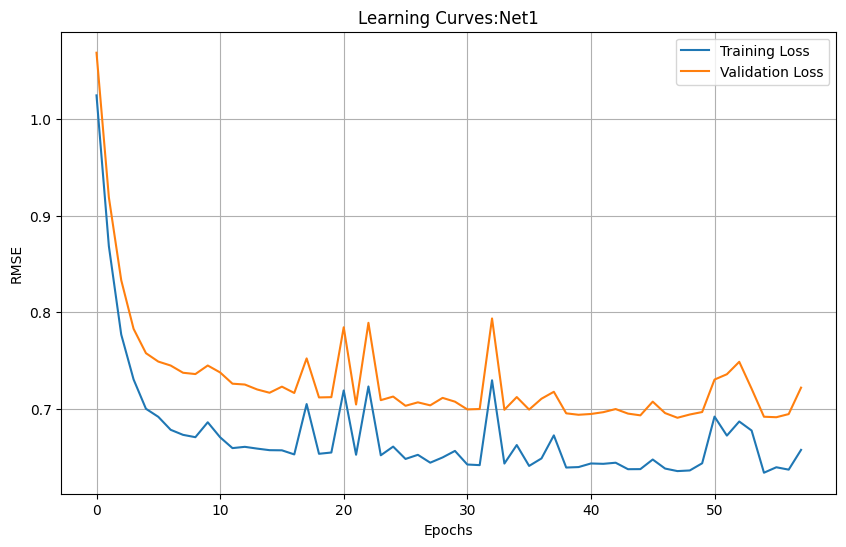

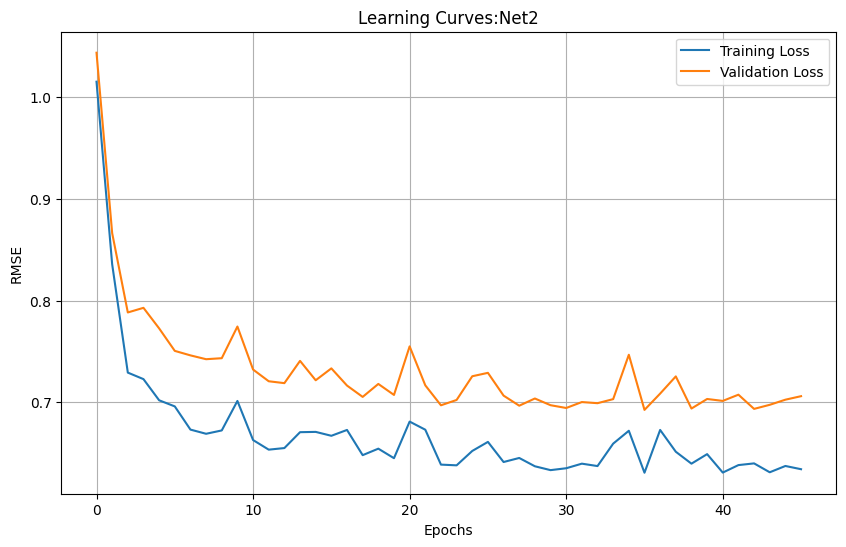

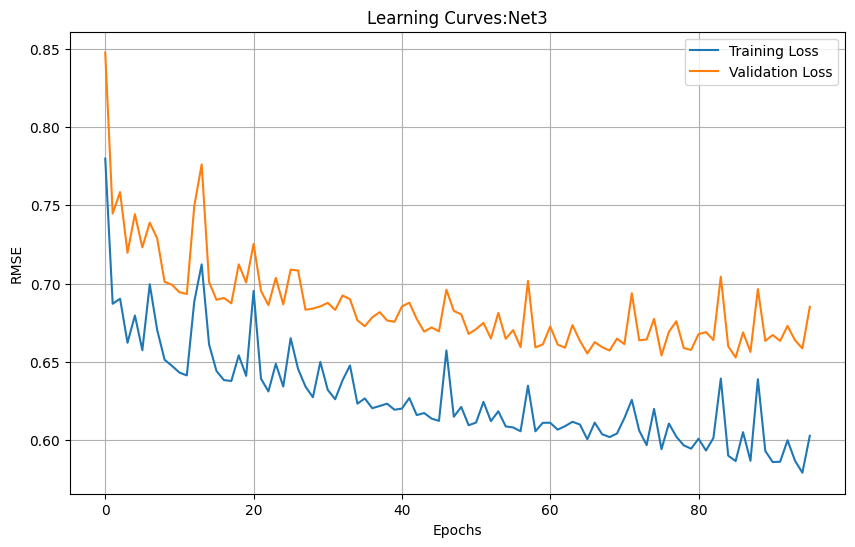

In [10]:
for net in networks:
    h = all_histories[net["name"]]
    plot_learning_curves(h["train"], h["val"], title=f"Learning Curves:{net['name']}")

In [11]:
best = min(results, key=lambda x: x["val_rmse"])
print(f"Best model: {best['name']}")

best_model = best_models[best["name"]]
best_model.eval()

test_rmse = evaluate(best_model, test_loader, loss_fn)

print(f"Test RMSE: {test_rmse:.4f}")
print(f"Average error: ${test_rmse * 100_000:,.0f} USD")

Best model: Net3
Test RMSE: 0.6106
Average error: $61,056 USD


## Conclusion
I found this activity interesting. I learned about the torch.clamp method and how to cap off the data with our calculated bounds. Integrating the preprocessing on nn.Module is good since it applies the transformations on the same neural network ensuring both consistency and performance wince we're applying it to the mini-bathces.